<a href="https://colab.research.google.com/github/nupoorsagar/Denoising_ECG/blob/main/claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
DRIVE_BASE   = '/content/drive/MyDrive/ecg_denoising_v3'
MITBIH_DIR   = f'{DRIVE_BASE}/mitbih'
NSTDB_DIR    = f'{DRIVE_BASE}/nstdb'
CACHE_FILE   = f'{DRIVE_BASE}/processed_data.npz'   # pre-processed windows
CKPT_DIR     = f'{DRIVE_BASE}/checkpoints'
RESULTS_DIR  = f'{DRIVE_BASE}/results'

for d in [MITBIH_DIR, NSTDB_DIR, CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive mounted. Directories ready.")


Drive mounted. Directories ready.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Install Dependencies
# ─────────────────────────────────────────────────────────────────────────────

# Run once, then Runtime → Restart session
!pip install wfdb --no-deps -q
!pip install pywavelets scikit-learn matplotlib seaborn tqdm -q



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.1 MB/s eta 0:00:00


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Imports & Config
# ─────────────────────────────────────────────────────────────────────────────

import math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import wfdb, pywt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ── Speed-up flags ────────────────────────────────────────────────────────────
torch.backends.cudnn.benchmark = True          # auto-tune cuDNN kernels
torch.set_float32_matmul_precision('high')     # allow TF32 on Ampere GPUs

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Hyper-parameters ──────────────────────────────────────────────────────────
FS          = 360     # MIT-BIH sampling rate
WINDOW_LEN  = 256     # ↓ from 512  → 4× fewer elements per sample = much faster
OVERLAP     = 128     # 50 % overlap
BATCH_SIZE  = 128     # ↑ from 64   → better GPU utilisation
SNR_LEVELS  = [-10, -5, 5, 10]

MITBIH_RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]
NSTDB_RECORDS = ['em', 'ma', 'bw']

BEAT_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}



Device : cpu


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Download Datasets (skips if already on Drive)
# ─────────────────────────────────────────────────────────────────────────────

def _already_downloaded(directory, records, ext='.dat'):
    """Return True if all records already exist on Drive."""
    return all(
        os.path.exists(os.path.join(directory, r + ext))
        for r in records
    )

if _already_downloaded(MITBIH_DIR, MITBIH_RECORDS):
    print("MIT-BIH already on Drive — skipping download.")
else:
    print("Downloading MIT-BIH records to Drive...")
    for rec in tqdm(MITBIH_RECORDS):
        try:
            wfdb.dl_database('mitdb', MITBIH_DIR, records=[rec])
        except Exception as e:
            print(f"  Warning {rec}: {e}")

if _already_downloaded(NSTDB_DIR, NSTDB_RECORDS):
    print("NSTDB already on Drive — skipping download.")
else:
    print("Downloading NSTDB records to Drive...")
    for rec in tqdm(NSTDB_RECORDS):
        try:
            wfdb.dl_database('nstdb', NSTDB_DIR, records=[rec])
        except Exception as e:
            print(f"  Warning {rec}: {e}")

print("Datasets ready.")


MIT-BIH already on Drive — skipping download.
NSTDB already on Drive — skipping download.
Datasets ready.


In [ ]:



# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Signal Utilities
# ─────────────────────────────────────────────────────────────────────────────

def load_mitbih_record(record_id, channel=0):
    path = os.path.join(MITBIH_DIR, record_id)
    try:
        signal, _ = wfdb.rdsamp(path, channels=[channel])
        sig = signal[:, 0].astype(np.float64)
    except Exception:
        rec = wfdb.rdrecord(path, physical=True, channels=[channel])
        sig = rec.p_signal[:, 0].astype(np.float64)
    sig = np.clip(sig, -10.0, 10.0)
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    ann = wfdb.rdann(path, 'atr')
    return sig, ann.symbol, ann.sample


def load_nstdb_noise(record_id, channel=0):
    path = os.path.join(NSTDB_DIR, record_id)
    try:
        signal, _ = wfdb.rdsamp(path, channels=[channel])
        sig = signal[:, 0].astype(np.float32)
    except Exception:
        rec = wfdb.rdrecord(path, physical=True, channels=[channel])
        sig = rec.p_signal[:, 0].astype(np.float32)
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    return (sig - sig.mean()) / (sig.std() + 1e-8)


def segment_signal(signal, window_len=WINDOW_LEN, overlap=OVERLAP):
    step   = window_len - overlap
    starts = np.arange(0, len(signal) - window_len + 1, step)
    return np.stack([signal[s:s + window_len] for s in starts]).astype(np.float32)


def normalize_windows(windows):
    mu  = windows.mean(axis=1, keepdims=True)
    std = windows.std(axis=1,  keepdims=True) + 1e-8
    return (windows - mu) / std


def add_noise_at_snr(clean, noise_template, target_snr_db):
    N, L        = clean.shape
    noise_tiled = np.tile(noise_template,
                          math.ceil(N * L / len(noise_template)))[:N * L]
    noise_tiled = noise_tiled.reshape(N, L).astype(np.float32)
    sig_pwr = np.mean(clean ** 2,       axis=1, keepdims=True)
    nse_pwr = np.mean(noise_tiled ** 2, axis=1, keepdims=True)
    scale   = np.sqrt(sig_pwr / (10 ** (target_snr_db / 10.0) * nse_pwr + 1e-12))
    return (clean + scale * noise_tiled).astype(np.float32)



In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Build / Load Processed Windows (cached on Drive)
# ─────────────────────────────────────────────────────────────────────────────
# The first run processes all records and saves a .npz to Drive.
# Every subsequent run (even after disconnect) loads in ~5 seconds.

if os.path.exists(CACHE_FILE):
    print(f"Loading cached windows from Drive: {CACHE_FILE}")
    cache = np.load(CACHE_FILE, allow_pickle=True)
    all_clean_windows = cache['windows']
    all_window_labels = cache['labels']
    print(f"Loaded {all_clean_windows.shape[0]:,} windows, "
          f"labels: {np.unique(all_window_labels)}")
else:
    print("Building windows from raw signals (one-time, ~5 min)...")
    all_clean_windows, all_window_labels = [], []
    loaded = 0

    for rec_id in tqdm(MITBIH_RECORDS):
        try:
            sig, symbols, samples = load_mitbih_record(rec_id)
        except Exception as e:
            print(f"  Skipping {rec_id}: {e}"); continue

        wins = normalize_windows(segment_signal(sig))
        step = WINDOW_LEN - OVERLAP

        for start in range(0, len(sig) - WINDOW_LEN + 1, step):
            mask   = (samples >= start) & (samples < start + WINDOW_LEN)
            beats  = [BEAT_MAP[s] for s in np.array(symbols)[mask] if s in BEAT_MAP]
            label  = max(set(beats), key=beats.count) if beats else 'N'
            all_window_labels.append(label)

        all_clean_windows.append(wins)
        loaded += 1

    if not all_clean_windows:
        raise RuntimeError("No records loaded — check Cell 4.")

    all_clean_windows = np.concatenate(all_clean_windows, axis=0)
    all_window_labels = np.array(all_window_labels[:len(all_clean_windows)])

    np.savez_compressed(CACHE_FILE,
                        windows=all_clean_windows,
                        labels=all_window_labels)
    print(f"Saved cache → {CACHE_FILE}")
    print(f"Loaded {loaded}/48 records | {all_clean_windows.shape[0]:,} windows")

label_dist = {k: int((all_window_labels == k).sum()) for k in np.unique(all_window_labels)}
print(f"Label distribution: {label_dist}")



Loading cached windows from Drive: /content/drive/MyDrive/ecg_denoising_v3/processed_data.npz
Loaded 243,696 windows, labels: ['F' 'N' 'Q' 'S' 'V']
Label distribution: {np.str_('F'): 1407, np.str_('N'): 211344, np.str_('Q'): 16076, np.str_('S'): 4670, np.str_('V'): 10199}


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Build Noise Datasets
# ─────────────────────────────────────────────────────────────────────────────

print("Loading NSTDB noise...")
noise_signals = {}
for rec_id in NSTDB_RECORDS:
    try:
        noise_signals[rec_id] = load_nstdb_noise(rec_id)
        print(f"  {rec_id}: {len(noise_signals[rec_id]):,} samples")
    except Exception as e:
        print(f"  {rec_id} failed: {e}")

if noise_signals:
    combined_noise = np.concatenate(list(noise_signals.values()))
    noisy_datasets = {snr: add_noise_at_snr(all_clean_windows, combined_noise, snr)
                      for snr in SNR_LEVELS}
else:
    print("WARNING: Falling back to Gaussian noise.")
    noisy_datasets = {snr: (all_clean_windows +
                            np.random.normal(0, 10**(-snr/20.), all_clean_windows.shape)
                            ).astype(np.float32)
                      for snr in SNR_LEVELS}

# Primary training noise = mix of -5 and +5 dB
primary_noisy = ((noisy_datasets[-5] + noisy_datasets[5]) / 2.0).astype(np.float32)
print("Noise datasets ready.")


Loading NSTDB noise...
  em: 650,000 samples
  ma: 650,000 samples
  bw: 650,000 samples
Noise datasets ready.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Train / Val / Test Split
# ─────────────────────────────────────────────────────────────────────────────

le             = LabelEncoder()
all_labels_enc = le.fit_transform(all_window_labels)
print(f"Classes: {le.classes_}")

indices = np.arange(len(all_clean_windows))
idx_train, idx_test = train_test_split(indices, test_size=0.20,
                                        random_state=SEED, stratify=all_labels_enc)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.25,
                                        random_state=SEED,
                                        stratify=all_labels_enc[idx_train])

X_train_clean, X_val_clean, X_test_clean = (
    all_clean_windows[idx_train],
    all_clean_windows[idx_val],
    all_clean_windows[idx_test],
)
X_train_noisy, X_val_noisy, X_test_noisy = (
    primary_noisy[idx_train],
    primary_noisy[idx_val],
    primary_noisy[idx_test],
)
y_train_lbl, y_val_lbl, y_test_lbl = (
    all_labels_enc[idx_train],
    all_labels_enc[idx_val],
    all_labels_enc[idx_test],
)
X_test_noisy_snr = {snr: noisy_datasets[snr][idx_test] for snr in SNR_LEVELS}

print(f"Train: {len(idx_train):,} | Val: {len(idx_val):,} | Test: {len(idx_test):,}")


Classes: ['F' 'N' 'Q' 'S' 'V']
Train: 146,217 | Val: 48,739 | Test: 48,740


In [ ]:





# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Dataset & DataLoaders
# ─────────────────────────────────────────────────────────────────────────────

class ECGDataset(Dataset):
    def __init__(self, noisy, clean, labels=None):
        # Keep on CPU as float32; pin_memory handles the rest
        self.X = torch.from_numpy(noisy).unsqueeze(1)
        self.Y = torch.from_numpy(clean).unsqueeze(1)
        self.L = torch.from_numpy(labels).long() if labels is not None else None

    def __len__(self): return len(self.X)

    def __getitem__(self, i):
        if self.L is not None:
            return self.X[i], self.Y[i], self.L[i]
        return self.X[i], self.Y[i]


# num_workers=4 + pin_memory keeps the GPU fed without waiting on CPU
def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=4, pin_memory=True, persistent_workers=True)

train_ds = ECGDataset(X_train_noisy, X_train_clean, y_train_lbl)
val_ds   = ECGDataset(X_val_noisy,   X_val_clean,   y_val_lbl)
test_ds  = ECGDataset(X_test_noisy,  X_test_clean,  y_test_lbl)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")



Batches — train: 1143 | val: 381 | test: 381


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Wavelet Loss  (vectorised, no Python loop per batch)
# ─────────────────────────────────────────────────────────────────────────────

class WaveletLoss(nn.Module):
    """
    MSE  +  alpha * Wavelet-coefficient MSE.
    Uses a learnable approximation via fixed 1-D conv filters derived from
    the db4 decomposition filters — fully on GPU, no numpy round-trip.
    """
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.mse   = nn.MSELoss()

        # db4 low-pass (scaling) decomposition filter coefficients
        db4_lo = np.array([
            -0.01059740178499, 0.03288301166698,  0.03084138183599,
            -0.18703481171888, -0.02798376941698, 0.63088076792959,
             0.71484657055292,  0.23037781330886
        ], dtype=np.float32)
        db4_hi = db4_lo[::-1].copy()
        db4_hi[1::2] *= -1

        # Register as non-trainable buffers (shape [1,1,8])
        lo = torch.tensor(db4_lo).view(1, 1, -1)
        hi = torch.tensor(db4_hi).view(1, 1, -1)
        self.register_buffer('lo', lo)
        self.register_buffer('hi', hi)

    def _one_level(self, x):
        """Single DWT level. x: [B, 1, L] → returns (approx, detail) each [B,1,L//2]."""
        pad = self.lo.shape[-1] - 1
        x_p = F.pad(x, (pad, pad), mode='reflect')
        approx = F.conv1d(x_p, self.lo, stride=2)
        detail = F.conv1d(x_p, self.hi, stride=2)
        return approx, detail

    def _dwt3(self, x):
        """3-level DWT. Returns concatenated coefficients as a flat vector."""
        a1, d1 = self._one_level(x)
        a2, d2 = self._one_level(a1)
        a3, d3 = self._one_level(a2)
        parts  = [a3, d3, d2, d1]
        return torch.cat([p.flatten(1) for p in parts], dim=1)

    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        wav_loss = F.mse_loss(self._dwt3(pred), self._dwt3(target))
        return (1 - self.alpha) * mse_loss + self.alpha * wav_loss



In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Model  (leaner version for faster training)
# ─────────────────────────────────────────────────────────────────────────────

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads,
                                          dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return self.norm(x + self.drop(out))


class CNN_Transformer_SAB(nn.Module):
    """
    Faster version:
      • Window 256 (was 512) — 4× fewer attention ops
      • d_model 64  (was 128) — 4× smaller Transformer
      • 1 Transformer layer (was 2)
    Still: CNN encoder → biGRU → PE → Transformer → SAB → CNN decoder
    """
    def __init__(self,
                 input_channels=1,
                 cnn_channels=32,       # was 64
                 kernel_size=7,
                 gru_hidden=32,         # was 64
                 gru_layers=1,
                 d_model=64,            # was 128
                 nhead=4,
                 num_transformer_layers=1,   # was 2
                 dropout=0.1):
        super().__init__()

        self.cnn_encoder = nn.Sequential(
            nn.Conv1d(input_channels, 16, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(16), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(16, cnn_channels, max(kernel_size-2,1),
                      padding=max(kernel_size-2,1)//2),
            nn.BatchNorm1d(cnn_channels), nn.GELU(), nn.Dropout(dropout),
        )

        self.bigru = nn.GRU(cnn_channels, gru_hidden, gru_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if gru_layers > 1 else 0.0)

        self.proj_in  = nn.Linear(gru_hidden * 2, d_model)
        self.pos_enc  = PositionalEncoding(d_model, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 2,   # was *4
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer,
                                                  num_layers=num_transformer_layers)

        self.sab      = SelfAttentionBlock(d_model, nhead, dropout)
        self.proj_out = nn.Linear(d_model, cnn_channels)

        self.cnn_decoder = nn.Sequential(
            nn.Conv1d(cnn_channels, 16, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(16), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(16, input_channels, max(kernel_size-2,1),
                      padding=max(kernel_size-2,1)//2),
        )

    def forward(self, x):
        e       = self.cnn_encoder(x).permute(0, 2, 1)
        g, _    = self.bigru(e)
        t       = self.pos_enc(self.proj_in(g))
        t       = self.sab(self.transformer(t))
        return  self.cnn_decoder(self.proj_out(t).permute(0, 2, 1))


# Sanity check
_x = torch.randn(2, 1, WINDOW_LEN).to(device)
_m = CNN_Transformer_SAB().to(device)
print(f"Output shape : {_m(_x).shape}")   # [2, 1, 256]
print(f"Parameters   : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _x, _m


Output shape : torch.Size([2, 1, 256])
Parameters   : 75,681


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Metrics
# ─────────────────────────────────────────────────────────────────────────────

def compute_snr(clean, denoised):
    noise   = denoised - clean
    return 10 * np.log10(np.mean(clean**2, axis=1) /
                         (np.mean(noise**2, axis=1) + 1e-12))

def compute_prd(clean, denoised):
    return 100 * np.sqrt(np.sum((clean-denoised)**2, axis=1) /
                         (np.sum(clean**2, axis=1) + 1e-12))

def compute_rmse(clean, denoised):
    return np.sqrt(np.mean((clean-denoised)**2, axis=1))


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Training Function  (with AMP mixed precision + Drive checkpointing)
# ─────────────────────────────────────────────────────────────────────────────

def train_model(model, train_loader, val_loader, criterion,
                lr=1e-3, num_epochs=30, scheduler_type='cosine',
                save_path='best.pth', verbose=True, use_amp=True):
    """
    Key speed-ups vs v2:
      • AMP (Automatic Mixed Precision): fp16 on GPU → ~2× faster
      • Gradient scaler prevents fp16 underflow
      • Checkpoint saved to Drive → survives runtime disconnects
      • Early stopping (patience=8) avoids wasted epochs
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler    = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type=='cuda'))

    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs, eta_min=lr*0.01)
    elif scheduler_type == 'onecycle':
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, epochs=num_epochs,
            steps_per_epoch=len(train_loader))
    elif scheduler_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=4, factor=0.5)
    else:
        scheduler = None

    history  = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val = float('inf')
    patience_counter = 0
    PATIENCE = 8   # stop if no improvement for 8 epochs

    for epoch in range(num_epochs):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        run = 0.0
        for batch in train_loader:
            x, y = batch[0].to(device, non_blocking=True), \
                   batch[1].to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)          # faster than zero_grad()
            with torch.cuda.amp.autocast(enabled=(use_amp and device.type=='cuda')):
                pred = model(x)
                loss = criterion(pred, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            run += loss.item()

            if scheduler_type == 'onecycle':
                scheduler.step()

        avg_train = run / len(train_loader)

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        v = 0.0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch[0].to(device, non_blocking=True), \
                        batch[1].to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(use_amp and device.type=='cuda')):
                    v += criterion(model(x), y).item()
        avg_val = v / len(val_loader)

        cur_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['lr'].append(cur_lr)

        if scheduler_type not in ('onecycle', None):
            (scheduler.step(avg_val) if scheduler_type == 'plateau'
             else scheduler.step())

        # ── Checkpoint on Drive ───────────────────────────────────────────
        if avg_val < best_val:
            best_val         = avg_val
            patience_counter = 0
            torch.save({
                'epoch':      epoch,
                'model':      model.state_dict(),
                'optimizer':  optimizer.state_dict(),
                'val_loss':   best_val,
            }, save_path)
        else:
            patience_counter += 1

        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Ep {epoch+1:03d}/{num_epochs} | "
                  f"Train: {avg_train:.5f} | Val: {avg_val:.5f} | "
                  f"LR: {cur_lr:.2e}")

        if patience_counter >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
            break

    print(f"  → Best Val Loss: {best_val:.5f}  [{save_path}]")
    return history



In [ ]:



# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Evaluation Utility
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_denoising(model, noisy_array, clean_array, batch_size=256):
    ds     = ECGDataset(noisy_array, clean_array)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=4, pin_memory=True)
    model.eval()
    preds_list, clean_list = [], []
    with torch.no_grad():
        for batch in loader:
            x, y = batch[0].to(device, non_blocking=True), \
                   batch[1].to(device, non_blocking=True)
            p = model(x).squeeze(1).cpu().numpy()
            preds_list.append(p)
            clean_list.append(y.squeeze(1).cpu().numpy())
    preds = np.concatenate(preds_list)
    clean = np.concatenate(clean_list)
    return preds, {
        'SNR_mean':  compute_snr(clean,  preds).mean(),
        'SNR_std':   compute_snr(clean,  preds).std(),
        'PRD_mean':  compute_prd(clean,  preds).mean(),
        'RMSE_mean': compute_rmse(clean, preds).mean(),
    }


def denoise_array(model, noisy_arr, clean_arr, batch_size=256):
    preds, _ = evaluate_denoising(model, noisy_arr, clean_arr, batch_size)
    return preds



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Train Final Model  (resume from Drive checkpoint if exists)
# ─────────────────────────────────────────────────────────────────────────────

FINAL_CKPT = f'{CKPT_DIR}/best_cnn_transformer_sab.pth'

model     = CNN_Transformer_SAB().to(device)
criterion = WaveletLoss(alpha=0.5)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

# Resume if a checkpoint already exists (after disconnect)
if os.path.exists(FINAL_CKPT):
    ckpt = torch.load(FINAL_CKPT, map_location=device)
    model.load_state_dict(ckpt['model'])
    print(f"Resumed from checkpoint (epoch {ckpt['epoch']+1}, "
          f"val_loss {ckpt['val_loss']:.5f})")
    ALREADY_TRAINED = True
else:
    ALREADY_TRAINED = False

if not ALREADY_TRAINED:
    print("\n=== Training Final Model ===")
    history = train_model(
        model, train_loader, val_loader, criterion,
        lr=1e-3, num_epochs=30, scheduler_type='cosine',
        save_path=FINAL_CKPT, verbose=True, use_amp=True,
    )

    # Plot training curves
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history['lr'])
    axes[1].set_title('LR Schedule'); axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150)
    plt.show()
else:
    print("Skipping training — using saved checkpoint.")

# Always load best weights
ckpt = torch.load(FINAL_CKPT, map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print("Model ready.")



Trainable parameters: 75,681
Resumed from checkpoint (epoch 2, val_loss 0.11789)
Skipping training — using saved checkpoint.
Model ready.



=== SNR Evaluation at Multiple Noise Levels ===
  -10 dB | In: -10.00 | Out:  +1.69 | Δ: +11.69 dB | PRD: 85.210%
   -5 dB | In:  -5.00 | Out:  +6.56 | Δ: +11.56 dB | PRD: 51.163%
   +5 dB | In:  +5.00 | Out:  +6.98 | Δ: +1.98 dB | PRD: 47.746%
  +10 dB | In: +10.00 | Out:  +6.03 | Δ: -3.97 dB | PRD: 53.213%


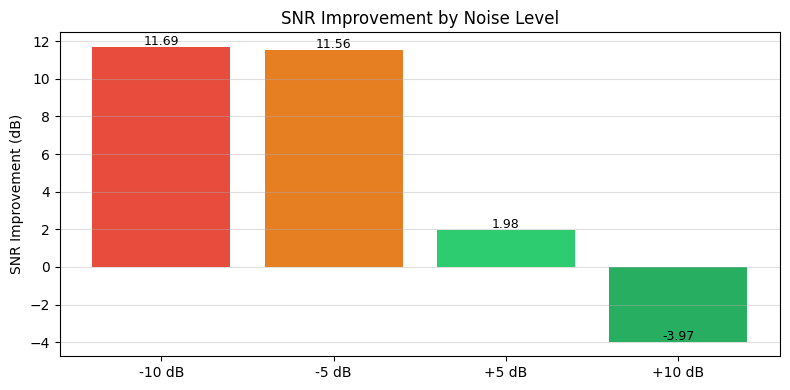

In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — SNR Evaluation at -10, -5, +5, +10 dB
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== SNR Evaluation at Multiple Noise Levels ===")
snr_results = {}

for snr_db in SNR_LEVELS:
    noisy_test  = X_test_noisy_snr[snr_db]
    _, metrics  = evaluate_denoising(model, noisy_test, X_test_clean)
    input_snr   = compute_snr(X_test_clean, noisy_test).mean()
    delta       = metrics['SNR_mean'] - input_snr
    snr_results[snr_db] = {
        'Input SNR (dB)':       input_snr,
        'Output SNR (dB)':      metrics['SNR_mean'],
        'SNR Improvement (dB)': delta,
        'PRD (%)':              metrics['PRD_mean'],
        'RMSE':                 metrics['RMSE_mean'],
    }
    print(f"  {snr_db:+3d} dB | In: {input_snr:+6.2f} | "
          f"Out: {metrics['SNR_mean']:+6.2f} | Δ: {delta:+5.2f} dB | "
          f"PRD: {metrics['PRD_mean']:.3f}%")

snr_df = pd.DataFrame(snr_results).T
snr_df.to_csv(f'{RESULTS_DIR}/snr_evaluation.csv')

fig, ax = plt.subplots(figsize=(8, 4))
vals  = [snr_results[s]['SNR Improvement (dB)'] for s in SNR_LEVELS]
bars  = ax.bar([f"{s:+d} dB" for s in SNR_LEVELS], vals,
               color=['#e74c3c','#e67e22','#2ecc71','#27ae60'])
ax.set_ylabel('SNR Improvement (dB)'); ax.set_title('SNR Improvement by Noise Level')
ax.grid(axis='y', alpha=0.4)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/snr_improvement.png', dpi=150)
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Ablation 1: Learning Rate  (5 epochs — for speed)
# ─────────────────────────────────────────────────────────────────────────────

LR_CANDIDATES = [1e-4, 5e-4, 1e-3, 5e-3]
lr_results     = {}

print("\n=== Ablation: Learning Rate (5 epochs each) ===")
for lr in LR_CANDIDATES:
    m = CNN_Transformer_SAB().to(device)
    h = train_model(m, train_loader, val_loader, criterion,
                    lr=lr, num_epochs=5, scheduler_type='cosine',
                    save_path=f'{CKPT_DIR}/abl_lr_{lr}.pth',
                    verbose=False, use_amp=True)
    lr_results[lr] = min(h['val_loss'])
    print(f"  LR={lr:.0e} → {lr_results[lr]:.5f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogx(list(lr_results.keys()), list(lr_results.values()), 'o-', color='steelblue')
ax.set_title('LR Ablation'); ax.set_xlabel('LR'); ax.set_ylabel('Val Loss'); ax.grid(True)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/ablation_lr.png', dpi=150); plt.show()




=== Ablation: Learning Rate (5 epochs each) ===


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Ablation 2: Kernel Size
# ─────────────────────────────────────────────────────────────────────────────

KERNEL_CANDIDATES = [3, 5, 7, 9, 11]
kernel_results     = {}

print("\n=== Ablation: Kernel Size (5 epochs each) ===")
for ks in KERNEL_CANDIDATES:
    m = CNN_Transformer_SAB(kernel_size=ks).to(device)
    h = train_model(m, train_loader, val_loader, criterion,
                    lr=1e-3, num_epochs=5, scheduler_type='cosine',
                    save_path=f'{CKPT_DIR}/abl_ks_{ks}.pth',
                    verbose=False, use_amp=True)
    kernel_results[ks] = min(h['val_loss'])
    print(f"  Kernel={ks} → {kernel_results[ks]:.5f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(kernel_results.keys()), list(kernel_results.values()),
        'o-', color='darkorange')
ax.set_title('Kernel Size Ablation'); ax.set_xlabel('Kernel'); ax.set_ylabel('Val Loss'); ax.grid(True)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/ablation_kernel.png', dpi=150); plt.show()


In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Ablation 3: GRU Hidden Units
# ─────────────────────────────────────────────────────────────────────────────

GRU_CANDIDATES = [16, 32, 64, 128]
gru_results     = {}

print("\n=== Ablation: GRU Hidden (5 epochs each) ===")
for h_dim in GRU_CANDIDATES:
    m    = CNN_Transformer_SAB(gru_hidden=h_dim).to(device)
    hist = train_model(m, train_loader, val_loader, criterion,
                       lr=1e-3, num_epochs=5, scheduler_type='cosine',
                       save_path=f'{CKPT_DIR}/abl_gru_{h_dim}.pth',
                       verbose=False, use_amp=True)
    gru_results[h_dim] = min(hist['val_loss'])
    print(f"  GRU hidden={h_dim} → {gru_results[h_dim]:.5f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(gru_results.keys()), list(gru_results.values()),
        'o-', color='forestgreen')
ax.set_title('GRU Hidden Ablation'); ax.set_xlabel('Hidden'); ax.set_ylabel('Val Loss'); ax.grid(True)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/ablation_gru.png', dpi=150); plt.show()



In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Ablation 4: Dropout
# ─────────────────────────────────────────────────────────────────────────────

DROPOUT_CANDIDATES = [0.0, 0.1, 0.2, 0.3, 0.5]
dropout_results     = {}

print("\n=== Ablation: Dropout (5 epochs each) ===")
for dp in DROPOUT_CANDIDATES:
    m = CNN_Transformer_SAB(dropout=dp).to(device)
    h = train_model(m, train_loader, val_loader, criterion,
                    lr=1e-3, num_epochs=5, scheduler_type='cosine',
                    save_path=f'{CKPT_DIR}/abl_dp_{dp}.pth',
                    verbose=False, use_amp=True)
    dropout_results[dp] = min(h['val_loss'])
    print(f"  Dropout={dp} → {dropout_results[dp]:.5f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(dropout_results.keys()), list(dropout_results.values()),
        'o-', color='purple')
ax.set_title('Dropout Ablation'); ax.set_xlabel('Dropout'); ax.set_ylabel('Val Loss'); ax.grid(True)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/ablation_dropout.png', dpi=150); plt.show()



In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Arrhythmia Classifier
# ─────────────────────────────────────────────────────────────────────────────

NUM_CLASSES = len(le.classes_)

class ECGClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32,  11, padding=5), nn.ReLU(), nn.BatchNorm1d(32),  nn.MaxPool1d(2),
            nn.Conv1d(32, 64,  7, padding=3), nn.ReLU(), nn.BatchNorm1d(64),  nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.ReLU(), nn.BatchNorm1d(128), nn.AdaptiveAvgPool1d(8),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x): return self.classifier(self.features(x))


class ECGClassDataset(Dataset):
    def __init__(self, signals, labels):
        self.X = torch.from_numpy(signals).unsqueeze(1)
        self.Y = torch.from_numpy(labels).long()
    def __len__(self):       return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]


def train_classifier(model, tr_ds, va_ds, num_epochs=15, lr=1e-3, tag=''):
    ld_tr   = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=4, pin_memory=True)
    ld_va   = DataLoader(va_ds, batch_size=BATCH_SIZE,
                         num_workers=4, pin_memory=True)
    opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sche    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    loss_fn = nn.CrossEntropyLoss()
    best, best_state = float('inf'), None

    for epoch in range(num_epochs):
        model.train()
        for x, y in ld_tr:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(device.type=='cuda')):
                loss = loss_fn(model(x), y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        sche.step()

        model.eval(); v = 0.0
        with torch.no_grad():
            for x, y in ld_va:
                v += loss_fn(model(x.to(device)), y.to(device)).item()
        v /= len(ld_va)
        if v < best:
            best = v
            best_state = {k: v_.clone() for k, v_ in model.state_dict().items()}
        if (epoch+1) % 5 == 0:
            print(f"  [{tag}] Ep {epoch+1}/{num_epochs} | Val Loss: {v:.4f}")

    model.load_state_dict(best_state)
    return model


def eval_classifier(model, signals, labels):
    ds  = ECGClassDataset(signals, labels)
    ld  = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=4, pin_memory=True)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in ld:
            preds.extend(model(x.to(device)).argmax(1).cpu().numpy())
            trues.extend(y.numpy())
    return np.array(preds), np.array(trues)


In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# CELL 22 — Train All 3 Classifiers
# ─────────────────────────────────────────────────────────────────────────────

# Denoise all splits first
print("Denoising train/val/test for classifier...")
X_test_denoised  = denoise_array(model, X_test_noisy,  X_test_clean)
X_train_denoised = denoise_array(model, X_train_noisy, X_train_clean)
X_val_denoised   = denoise_array(model, X_val_noisy,   X_val_clean)

print("\n=== Classifier — CLEAN ===")
clf_clean = ECGClassifier().to(device)
clf_clean = train_classifier(clf_clean,
    ECGClassDataset(X_train_clean, y_train_lbl),
    ECGClassDataset(X_val_clean,   y_val_lbl), tag='CLEAN')

print("\n=== Classifier — NOISY ===")
clf_noisy = ECGClassifier().to(device)
clf_noisy = train_classifier(clf_noisy,
    ECGClassDataset(X_train_noisy, y_train_lbl),
    ECGClassDataset(X_val_noisy,   y_val_lbl), tag='NOISY')

print("\n=== Classifier — DENOISED ===")
clf_denoised = ECGClassifier().to(device)
clf_denoised = train_classifier(clf_denoised,
    ECGClassDataset(X_train_denoised, y_train_lbl),
    ECGClassDataset(X_val_denoised,   y_val_lbl), tag='DENOISED')


In [ ]:


# ─────────────────────────────────────────────────────────────────────────────
# CELL 23 — Classification Comparison
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== Classification Report Comparison ===\n")
class_names = list(le.classes_)
results_clf = {}

for tag, clf, signals in [
    ('CLEAN',    clf_clean,    X_test_clean),
    ('NOISY',    clf_noisy,    X_test_noisy),
    ('DENOISED', clf_denoised, X_test_denoised),
]:
    preds, trues = eval_classifier(clf, signals, y_test_lbl)
    acc = (preds == trues).mean() * 100
    results_clf[tag] = {'accuracy': acc, 'preds': preds, 'trues': trues}
    print(f"── {tag} ──")
    print(classification_report(trues, preds, target_names=class_names, digits=4))

# Accuracy bar
fig, ax = plt.subplots(figsize=(7, 4))
tags  = list(results_clf.keys())
accs  = [results_clf[t]['accuracy'] for t in tags]
bars  = ax.bar(tags, accs, color=['#2ecc71','#e74c3c','#3498db'], width=0.5)
ax.set_ylim(0, 112); ax.set_ylabel('Accuracy (%)')
ax.set_title('Arrhythmia Classification: Clean vs Noisy vs Denoised')
ax.grid(axis='y', alpha=0.4)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/classification_comparison.png', dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (tag, res) in zip(axes, results_clf.items()):
    cm = confusion_matrix(res['trues'], res['preds'])
    sns.heatmap(cm.astype(float)/cm.sum(axis=1,keepdims=True)*100,
                annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{tag} ({res["accuracy"]:.2f}%)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrices.png', dpi=150)
plt.show()



In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 24 — Waveform Visualisation
# ─────────────────────────────────────────────────────────────────────────────

IDX = 0
t   = np.arange(WINDOW_LEN) / FS * 1000

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t, X_test_noisy[IDX],    color='#e74c3c', lw=0.8, label='Noisy')
axes[1].plot(t, X_test_denoised[IDX], color='#3498db', lw=1.0, label='Denoised')
axes[2].plot(t, X_test_clean[IDX],    color='#2ecc71', lw=1.0, label='Clean Reference')
for ax in axes:
    ax.legend(loc='upper right'); ax.set_ylabel('Amplitude'); ax.grid(alpha=0.3)
axes[2].set_xlabel('Time (ms)')
plt.suptitle('ECG Denoising — CNN + Transformer + Self-Attention', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/waveform_comparison.png', dpi=150)
plt.show()



In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# CELL 25 — Final Export
# ─────────────────────────────────────────────────────────────────────────────

preds_final, _ = evaluate_denoising(model, X_test_noisy, X_test_clean)
snr_out  = compute_snr(X_test_clean,  preds_final)
snr_in   = compute_snr(X_test_clean,  X_test_noisy)
prd_out  = compute_prd(X_test_clean,  preds_final)
rmse_out = compute_rmse(X_test_clean, preds_final)

pd.DataFrame({
    'index':           np.arange(len(preds_final)),
    'label':           le.inverse_transform(y_test_lbl),
    'SNR_input_dB':    snr_in,
    'SNR_output_dB':   snr_out,
    'SNR_improvement': snr_out - snr_in,
    'PRD':             prd_out,
    'RMSE':            rmse_out,
}).to_csv(f'{RESULTS_DIR}/final_test_metrics.csv', index=False)

print("\n=== Final Test Metrics ===")
print(f"  Input  SNR : {snr_in.mean():.3f} dB")
print(f"  Output SNR : {snr_out.mean():.3f} dB")
print(f"  SNR Δ      : {(snr_out-snr_in).mean():.3f} dB")
print(f"  PRD        : {prd_out.mean():.4f} %")
print(f"  RMSE       : {rmse_out.mean():.6f}")

print("\n=== Classification ===")
for tag, res in results_clf.items():
    print(f"  {tag:>9s}: {res['accuracy']:.2f}%")

print(f"\n✅  All results saved to {RESULTS_DIR}")


=== SNR Evaluation at Multiple Noise Levels ===


KeyboardInterrupt: 